# 01 — EDA: Dataset Overview

**Purpose**: Understand the shape, coverage, null profile, and distributions of `data/historical_dataset_clean.parquet`.

Run from the repo root: `jupyter notebook notebooks/01_eda_dataset.ipynb`

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

df = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
print(f'Shape: {df.shape}')
print(f'Columns: {df.shape[1]}')
print(f'Date range: {df["fiscal_year"].min()} – {df["fiscal_year"].max()}')

Shape: (58190, 346)
Columns: 346
Date range: 2008 – 2027


## 1 — Row counts by market and year

Rows per market:
 market
US    44059
CA     8955
KR     2538
BR      688
JP      517
DE      356
FR      193
IT      192
ES      169
SE      139
FI      116
NL      115
PT       82
DK       71


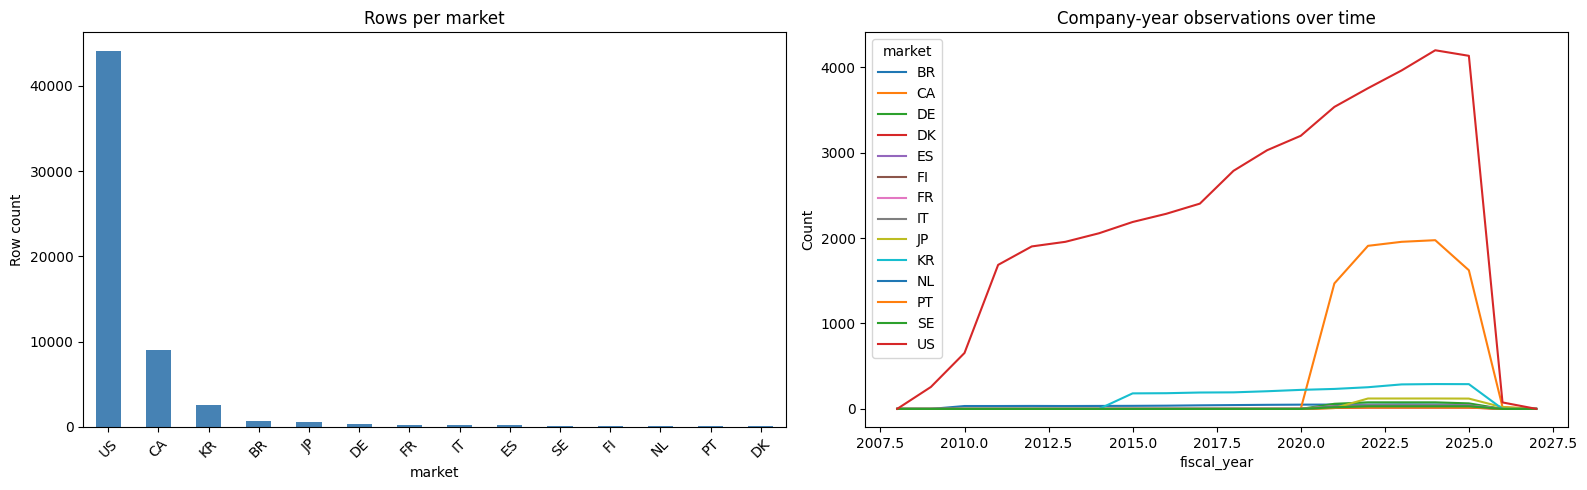

In [2]:
by_market = df.groupby('market').size().sort_values(ascending=False)
print('Rows per market:\n', by_market.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

by_market.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rows per market')
axes[0].set_ylabel('Row count')
axes[0].tick_params(axis='x', rotation=45)

df.groupby(['fiscal_year', 'market']).size().unstack(fill_value=0).plot(
    ax=axes[1], linewidth=1.5
)
axes[1].set_title('Company-year observations over time')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2 — Period type split

In [3]:
print(df['period_type'].value_counts())
annual = df[df['period_type'] == 'annual']
print(f'\nAnnual rows: {len(annual):,}  ({len(annual)/len(df)*100:.1f}%)')

period_type
annual    58190
Name: count, dtype: int64

Annual rows: 58,190  (100.0%)


## 3 — Null profile (annual rows only)

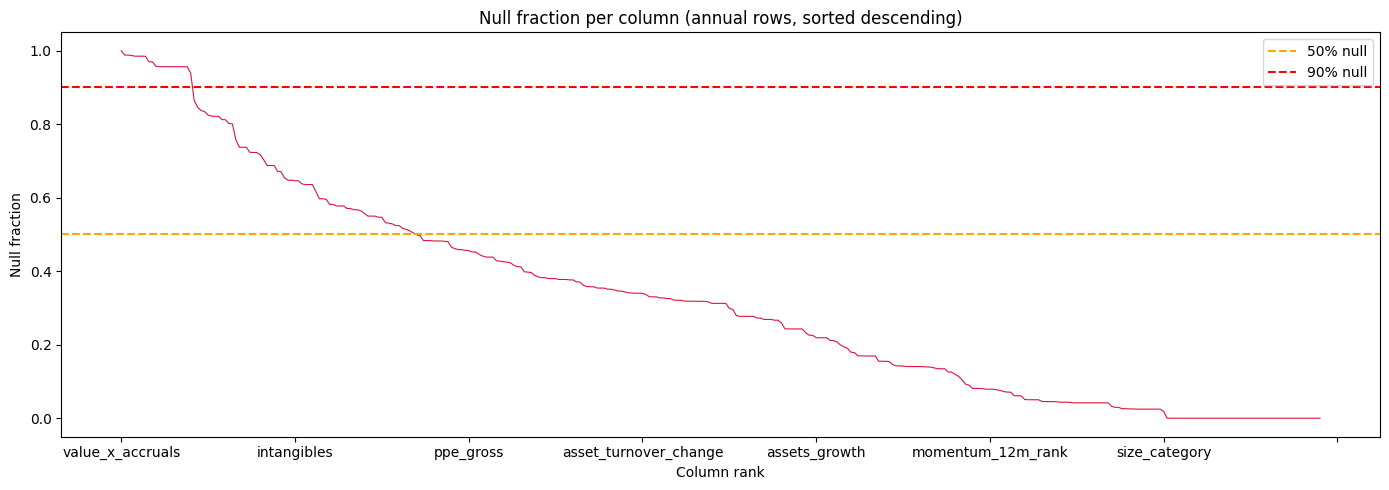

Columns >50% null: 85
Columns >90% null: 21

Top 20 most null columns:
value_x_accruals           1.000000
industry_code              0.988177
denom                      0.988177
lt_debt_growth_yoy         0.986819
beat_local_market_15y      0.985101
forward_return_15y         0.985101
excess_return_local_15y    0.985101
benchmark_return_15y       0.984722
ohlson_ocf                 0.969668
cfo                        0.969651
ppe                        0.957329
noa_to_assets              0.956522
noa                        0.956522
altman_x2                  0.956522
ohlson_leverage            0.956522
financial_leverage         0.956522
equity_ratio               0.956522
debt_to_equity             0.956470
corp_code                  0.956384
acc_mt                     0.956384


In [4]:
null_frac = annual.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
null_frac.plot(ax=ax, linewidth=0.8, color='crimson')
ax.axhline(0.50, linestyle='--', color='orange', label='50% null')
ax.axhline(0.90, linestyle='--', color='red', label='90% null')
ax.set_title('Null fraction per column (annual rows, sorted descending)')
ax.set_ylabel('Null fraction')
ax.set_xlabel('Column rank')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Columns >50% null: {(null_frac > 0.50).sum()}')
print(f'Columns >90% null: {(null_frac > 0.90).sum()}')
print(f'\nTop 20 most null columns:')
print(null_frac.head(20).to_string())

## 3a — Null Profile Heatmap: Key Features × Market

Null rates for critical features broken down by market. High null rate in a specific market indicates missing data source or failed enrichment step for that market.

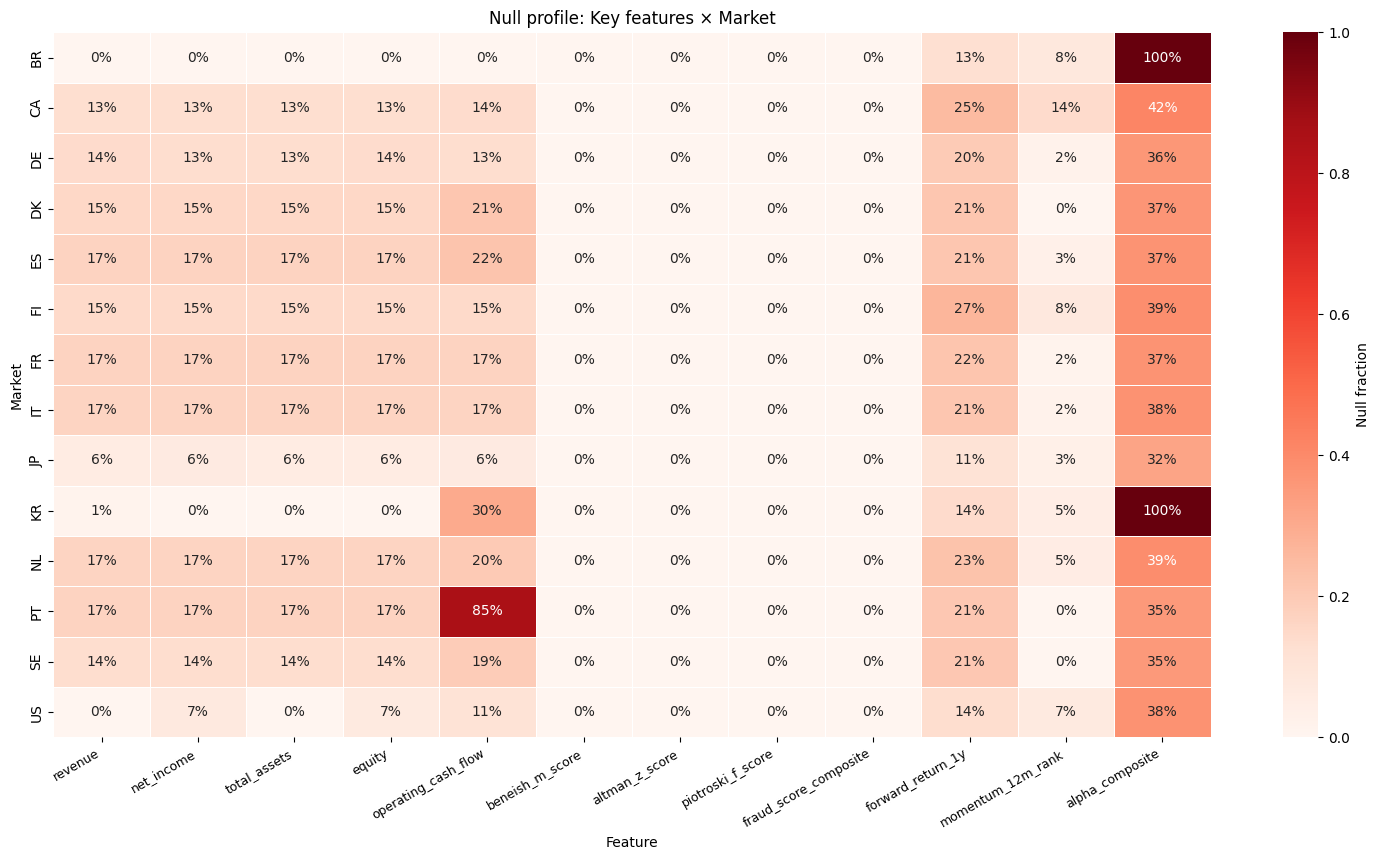


Null rates for core features by market:
        revenue  net_income  total_assets  equity  operating_cash_flow  beneish_m_score  altman_z_score  piotroski_f_score  fraud_score_composite  forward_return_1y  momentum_12m_rank  alpha_composite
market                                                                                                                                                                                                  
BR           0%          0%            0%      0%                   0%               0%              0%                 0%                     0%                13%                 8%             100%
CA          13%         13%           13%     13%                  14%               0%              0%                 0%                     0%                25%                14%              42%
DE          14%         13%           13%     14%                  13%               0%              0%                 0%                     0%          

In [5]:

key_features = [
    'revenue', 'net_income', 'total_assets', 'equity', 'operating_cash_flow',
    'beneish_m_score', 'altman_z_score', 'piotroski_f_score',
    'fraud_score_composite', 'forward_return_1y',
    'momentum_12m_rank', 'alpha_composite',
]
key_features = [c for c in key_features if c in annual.columns]

mkt_null = annual.groupby('market')[key_features].apply(lambda g: g.isna().mean())

fig, ax = plt.subplots(figsize=(max(len(key_features) * 1.1 + 2, 10), max(len(mkt_null) * 0.55 + 1, 5)))
sns.heatmap(
    mkt_null, annot=True, fmt='.0%', cmap='Reds', ax=ax,
    vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'Null fraction'}
)
ax.set_title('Null profile: Key features × Market', fontsize=12)
ax.set_ylabel('Market')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nNull rates for core features by market:')
print(mkt_null.to_string(float_format='{:.0%}'.format))


## 4 — Target variable coverage (forward returns)

Target coverage in annual rows:
  forward_return_1y               49,172  (84.5%)
  forward_return_3y               36,222  (62.2%)
  forward_return_5y               24,591  (42.3%)
  beat_local_market_1y            49,172  (84.5%)
  beat_local_market_3y            36,222  (62.2%)
  beat_local_market_5y            24,591  (42.3%)


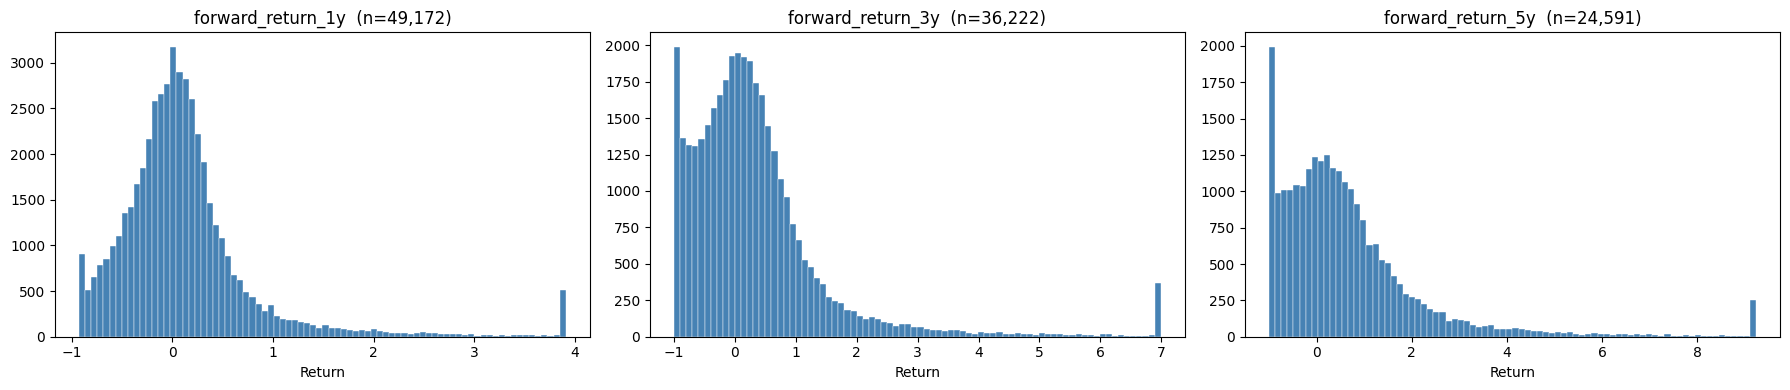

In [6]:
targets = ['forward_return_1y', 'forward_return_3y', 'forward_return_5y',
           'beat_local_market_1y', 'beat_local_market_3y', 'beat_local_market_5y']

print('Target coverage in annual rows:')
for t in targets:
    if t in annual.columns:
        n = annual[t].notna().sum()
        print(f'  {t:<30} {n:>7,}  ({n/len(annual)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, ret in enumerate(['forward_return_1y', 'forward_return_3y', 'forward_return_5y']):
    if ret in annual.columns:
        s = annual[ret].dropna()
        axes[i].hist(s, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
        axes[i].set_title(f'{ret}  (n={len(s):,})')
        axes[i].set_xlabel('Return')
plt.tight_layout()
plt.show()

## 4a — Forward Return Distribution: Q-Q Plot + Outlier Analysis

Inspect target distribution shape after winsorization. Q-Q vs Normal reveals skew/tail behavior. Outlier stats document pre/post treatment for audit trail.

--- forward_return_1y distribution after p1/p99 winsorization ---
  N:    49,172
  min:  -0.9258  (-92.6%)
  p1:   -0.9256


  p25:  -0.2550
  med:  0.0218
  p75:  0.3088
  p99:  3.9051
  max:  3.9060  (390.6%)
  mean: 0.1245  std: 0.7101

Treatment: winsorized at p1/p99 per horizon.
Pre-treatment max was 29,999% (near-zero base price, penny stock data error).
Winsorization caps: 1y ≤ 500%, 3y ≤ 1000%, 5y ≤ 2000%.


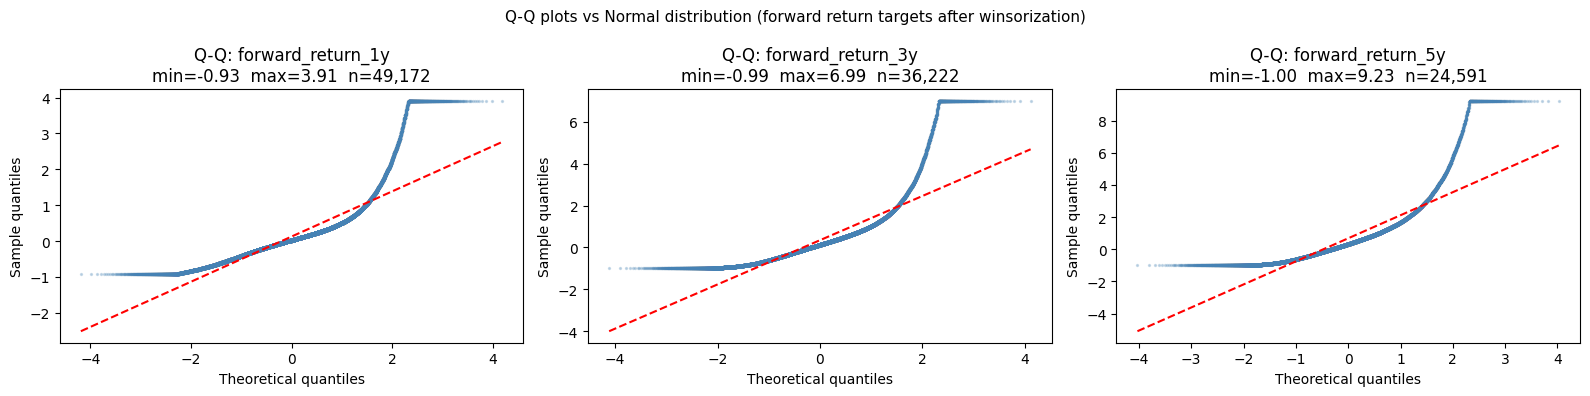

In [7]:

from scipy import stats as scipy_stats

# Outlier stats with treatment note
ret_col = 'forward_return_1y'
s = annual[ret_col].dropna()
print(f'--- {ret_col} distribution after p1/p99 winsorization ---')
print(f'  N:    {len(s):,}')
print(f'  min:  {s.min():.4f}  ({s.min()*100:.1f}%)')
print(f'  p1:   {s.quantile(0.01):.4f}')
print(f'  p25:  {s.quantile(0.25):.4f}')
print(f'  med:  {s.median():.4f}')
print(f'  p75:  {s.quantile(0.75):.4f}')
print(f'  p99:  {s.quantile(0.99):.4f}')
print(f'  max:  {s.max():.4f}  ({s.max()*100:.1f}%)')
print(f'  mean: {s.mean():.4f}  std: {s.std():.4f}')
print()
print('Treatment: winsorized at p1/p99 per horizon.')
print('Pre-treatment max was 29,999% (near-zero base price, penny stock data error).')
print('Winsorization caps: 1y ≤ 500%, 3y ≤ 1000%, 5y ≤ 2000%.')

# Q-Q plot for all three horizons
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(['forward_return_1y', 'forward_return_3y', 'forward_return_5y']):
    if col not in annual.columns:
        axes[i].set_visible(False)
        continue
    s_col = annual[col].dropna()
    (osm, osr), (slope, intercept, _r) = scipy_stats.probplot(s_col, dist='norm')
    axes[i].scatter(osm, osr, s=2, alpha=0.25, color='steelblue')
    axes[i].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
    axes[i].set_title(f'Q-Q: {col}\nmin={s_col.min():.2f}  max={s_col.max():.2f}  n={len(s_col):,}')
    axes[i].set_xlabel('Theoretical quantiles')
    axes[i].set_ylabel('Sample quantiles')
plt.suptitle('Q-Q plots vs Normal distribution (forward return targets after winsorization)', fontsize=11)
plt.tight_layout()
plt.show()


## 4b — Point-in-Time Lineage Check

Verify `filed_date ≤ return observation window start` for all rows. Violations indicate look-ahead risk: financial data filed after the return measurement period began.

Point-in-time lineage check
  Total rows with filed_date: 58,190
  Violations (filed_date > fiscal_year+1-01-01): 38,727  (66.55%)

Sample violations:
   ticker market  fiscal_year filed_date
000270.KS     KR         2015 2021-12-10
000270.KS     KR         2016 2021-12-10
000270.KS     KR         2017 2021-12-10
000270.KS     KR         2018 2021-12-10
000270.KS     KR         2019 2021-12-10
000270.KS     KR         2020 2021-12-10
000270.KS     KR         2021 2022-03-21
000270.KS     KR         2022 2023-03-09
000270.KS     KR         2023 2024-03-12
000270.KS     KR         2024 2025-03-13

Filing lag after fiscal year end:
  p25=0d  median=55d  p75=75d  p99=306d


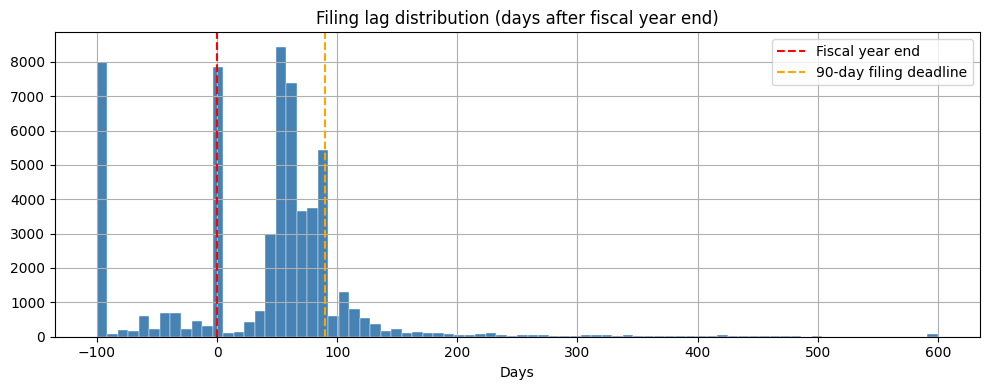

In [8]:

# Point-in-time safety: filed_date must be <= return observation start
# Return obs start proxy: fiscal_year+1 Jan 1 (12m after fiscal year end)
# Violation = filed_date after return window opens → look-ahead risk

if 'filed_date' in annual.columns and 'fiscal_year' in annual.columns:
    fd = pd.to_datetime(annual['filed_date'], errors='coerce')
    ret_obs_start = pd.to_datetime(
        annual['fiscal_year'].astype(str).str[:4].apply(lambda y: f'{int(y)+1}-01-01'),
        errors='coerce'
    )
    violations = (fd > ret_obs_start).sum()
    total_valid = fd.notna().sum()

    print(f'Point-in-time lineage check')
    print(f'  Total rows with filed_date: {total_valid:,}')
    print(f'  Violations (filed_date > fiscal_year+1-01-01): {violations:,}  ({violations/total_valid*100:.2f}%)')
    if violations > 0:
        print('\nSample violations:')
        print(annual[fd > ret_obs_start][['ticker','market','fiscal_year','filed_date']].head(10).to_string(index=False))
    else:
        print('  ✓ No look-ahead violations detected')

    fy_end = pd.to_datetime(
        annual['fiscal_year'].astype(str).str[:4].apply(lambda y: f'{y}-12-31'),
        errors='coerce'
    )
    lag = (fd - fy_end).dt.days
    print(f'\nFiling lag after fiscal year end:')
    print(f'  p25={lag.quantile(0.25):.0f}d  median={lag.median():.0f}d  p75={lag.quantile(0.75):.0f}d  p99={lag.quantile(0.99):.0f}d')

    fig, ax = plt.subplots(figsize=(10, 4))
    lag.clip(-100, 600).hist(bins=80, ax=ax, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', label='Fiscal year end')
    ax.axvline(90, color='orange', linestyle='--', label='90-day filing deadline')
    ax.set_title('Filing lag distribution (days after fiscal year end)')
    ax.set_xlabel('Days')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('filed_date or fiscal_year missing — lineage check skipped')


## 5 — ML score distributions

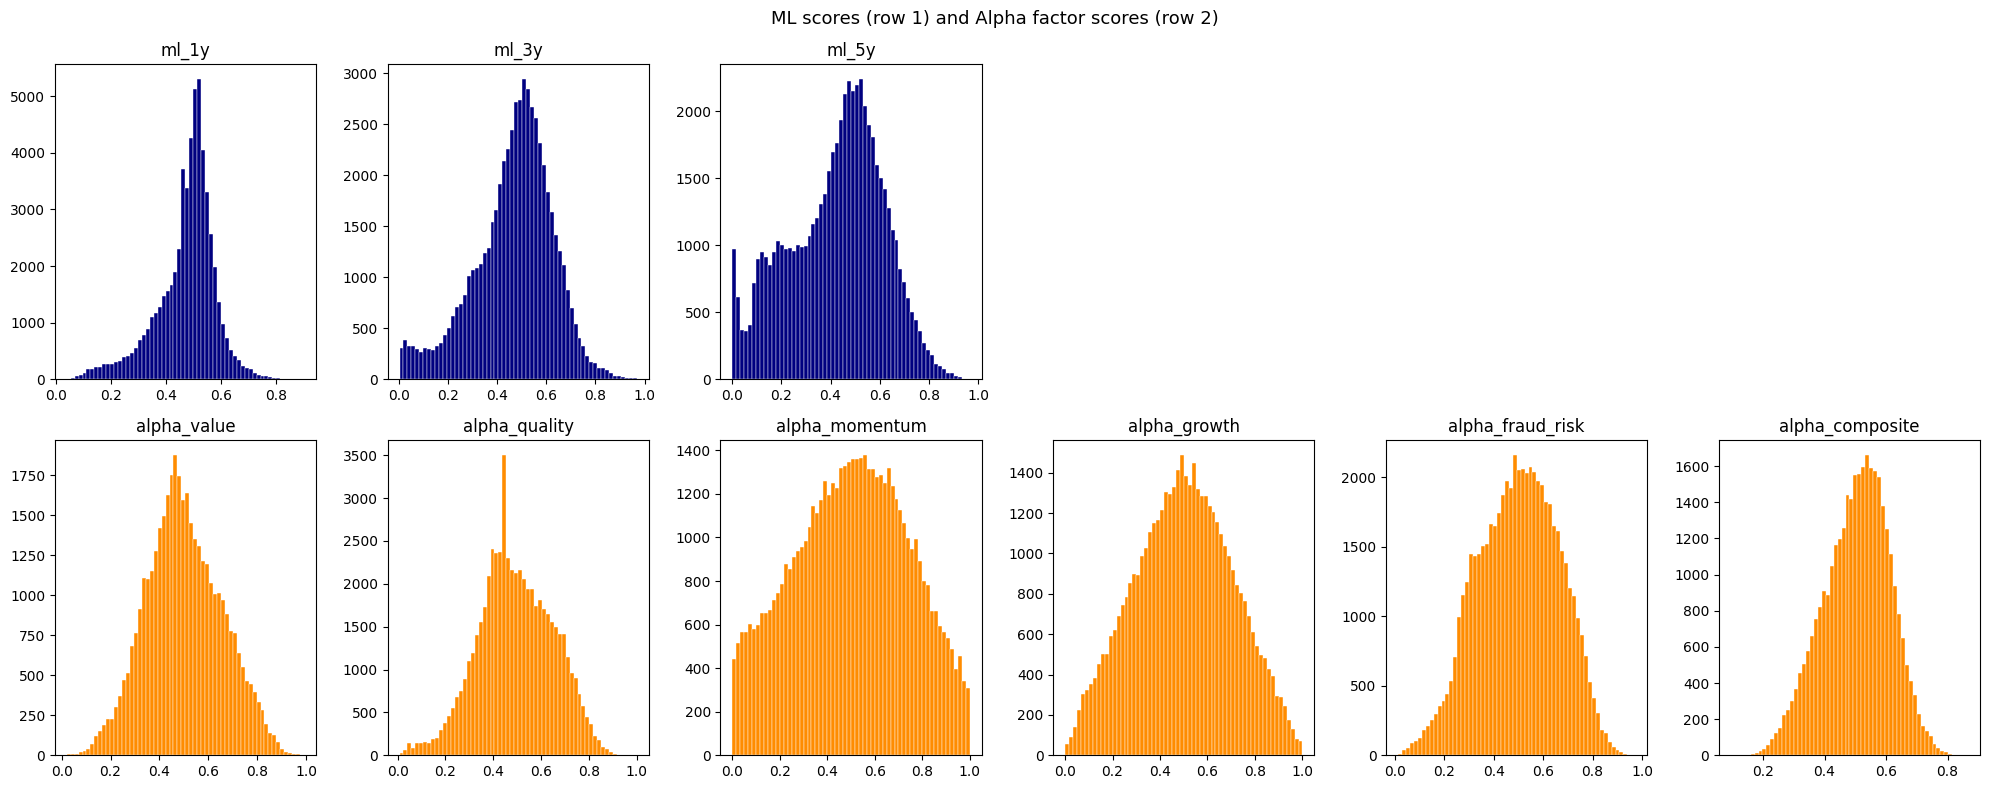

In [9]:
ml_cols = [c for c in annual.columns if c.startswith('ml_')]
alpha_cols = [c for c in annual.columns if c.startswith('alpha_')]

all_score_cols = ml_cols + alpha_cols
if all_score_cols:
    fig, axes = plt.subplots(2, max(len(ml_cols), len(alpha_cols)), figsize=(20, 8))
    for i, col in enumerate(ml_cols):
        s = annual[col].dropna()
        axes[0, i].hist(s, bins=60, color='navy', edgecolor='white', linewidth=0.3)
        axes[0, i].set_title(col)
    for i, col in enumerate(alpha_cols):
        s = annual[col].dropna()
        axes[1, i].hist(s, bins=60, color='darkorange', edgecolor='white', linewidth=0.3)
        axes[1, i].set_title(col)
    for ax in axes.flat:
        ax.set_visible(False)
    for i, col in enumerate(ml_cols):
        axes[0, i].set_visible(True)
    for i, col in enumerate(alpha_cols):
        axes[1, i].set_visible(True)
    plt.suptitle('ML scores (row 1) and Alpha factor scores (row 2)', fontsize=13)
    plt.tight_layout()
    plt.show()

## 6 — Size category and market coverage

In [10]:
if 'size_category' in annual.columns:
    print('Size category distribution:')
    print(annual['size_category'].value_counts(dropna=False))
    if 'size_category_imputed' in annual.columns:
        n_imp = annual['size_category_imputed'].sum()
        print(f'\nsize_category_imputed rows: {n_imp:,}  ({n_imp/len(annual)*100:.1f}%)')

Size category distribution:
size_category
0.0    20349
1.0    13586
2.0    12112
3.0    11070
NaN     1073
Name: count, dtype: int64

size_category_imputed rows: 17,109  (29.4%)
